In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv('/kaggle/input/datasets/maajdl/yeh-concret-data/Concrete_Data_Yeh.csv')
df.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.isnull().sum()

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

In [5]:
df.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [6]:
pt = PowerTransformer(method = 'box-cox')
df['age_pt'] = pt.fit_transform(df[['age']])

((array([-3.20610174, -2.94154129, -2.79394753, ...,  2.79394753,
          2.94154129,  3.20610174]),
  array([  1,   1,   3, ..., 365, 365, 365])),
 (np.float64(48.64057467250515),
  np.float64(45.662135922330094),
  np.float64(0.7682840063948203)))

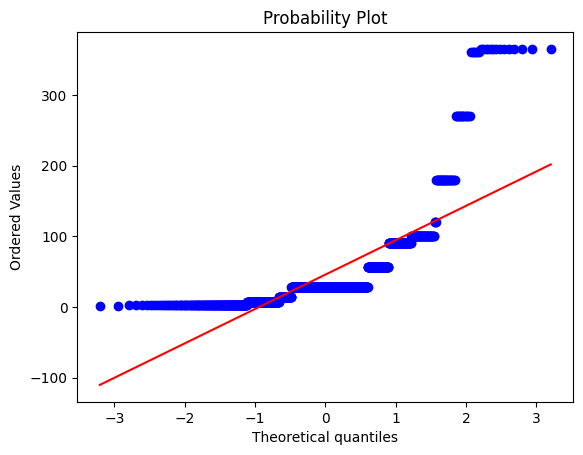

In [7]:
stats.probplot(df['age'],dist='norm',plot=plt)


((array([-3.20610174, -2.94154129, -2.79394753, ...,  2.79394753,
          2.94154129,  3.20610174]),
  array([-2.49682794, -2.49682794, -1.68334077, ...,  2.43342426,
          2.43342426,  2.43342426])),
 (np.float64(0.9659474654949564),
  np.float64(2.740596425455318e-16),
  np.float64(0.9633319101676722)))

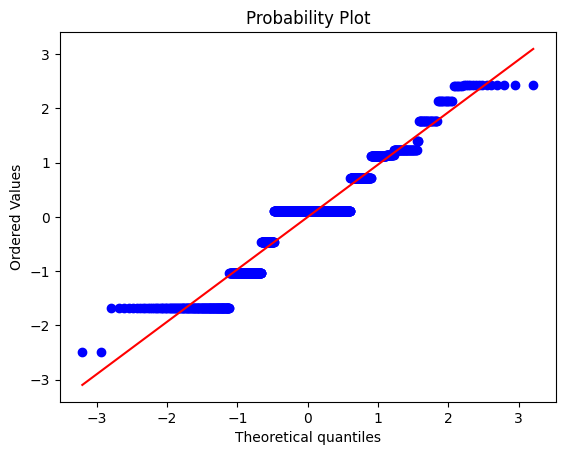

In [8]:
stats.probplot(df['age_pt'],dist='norm',plot=plt)

In [9]:
df.drop(columns=['age_pt'],inplace=True)
df.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


((array([-3.20610174, -2.94154129, -2.79394753, ...,  2.79394753,
          2.94154129,  3.20610174]),
  array([121.8, 121.8, 121.8, ..., 237. , 246.9, 247. ])),
 (np.float64(21.1947673420299),
  np.float64(181.56728155339806),
  np.float64(0.9903263490279391)))

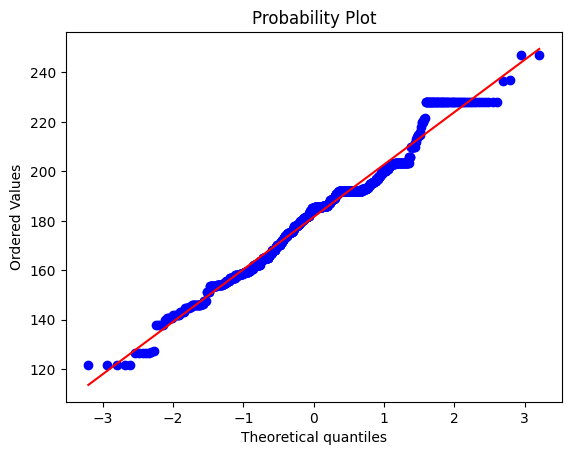

In [10]:
stats.probplot(df['water'],dist='norm',plot=plt)


((array([-3.20610174, -2.94154129, -2.79394753, ...,  2.79394753,
          2.94154129,  3.20610174]),
  array([-2.88810548, -2.88810548, -2.88810548, ...,  2.53837334,
          2.97712381,  2.98153833])),
 (np.float64(0.9933129763793336),
  np.float64(1.4345133758217541e-15),
  np.float64(0.9906233217761214)))

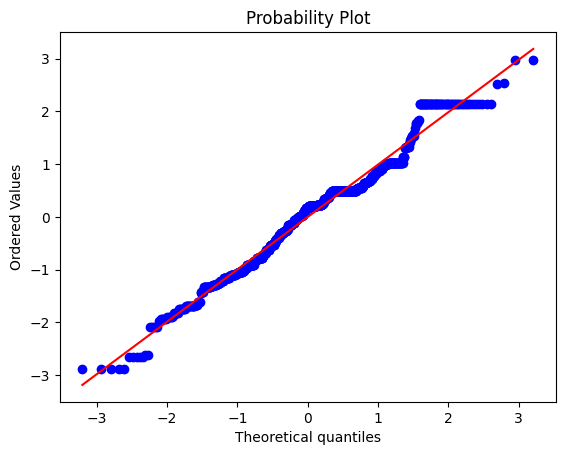

In [11]:
df['water_pt'] = pt.fit_transform(df[['water']])
stats.probplot(df['water_pt'],dist='norm',plot=plt)


((array([-3.20610174, -2.94154129, -2.79394753, ...,  2.79394753,
          2.94154129,  3.20610174]),
  array([-2.88810548, -2.88810548, -2.88810548, ...,  2.53837334,
          2.97712381,  2.98153833])),
 (np.float64(0.9933129763793336),
  np.float64(1.4345133758217541e-15),
  np.float64(0.9906233217761214)))

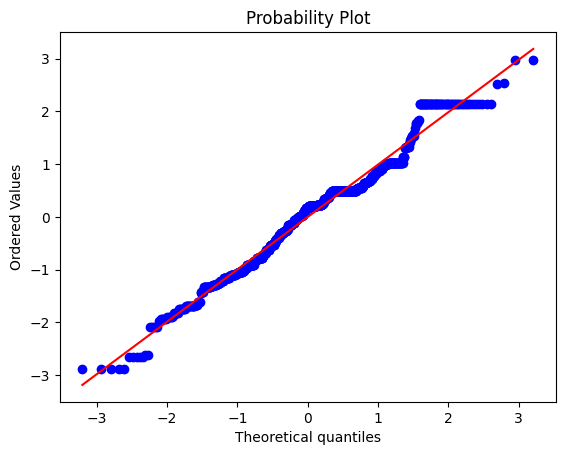

In [12]:
pt2 = PowerTransformer(method='box-cox')
df['water_pt2'] = pt2.fit_transform(df[['water']])
stats.probplot(df['water_pt2'],dist='norm',plot=plt)

# Power tranformation in age
thier was no effect on water col, but it improved the age column significatly

> niether box-cox, nor yeo johnson affected the water column

((array([-3.20610174, -2.94154129, -2.79394753, ...,  2.79394753,
          2.94154129,  3.20610174]),
  array([-2.88808501, -2.88808501, -2.88808501, ...,  2.53833673,
          2.977063  ,  2.98147725])),
 (np.float64(0.993313193982494),
  np.float64(-1.6560025890675092e-15),
  np.float64(0.9906235387900642)))

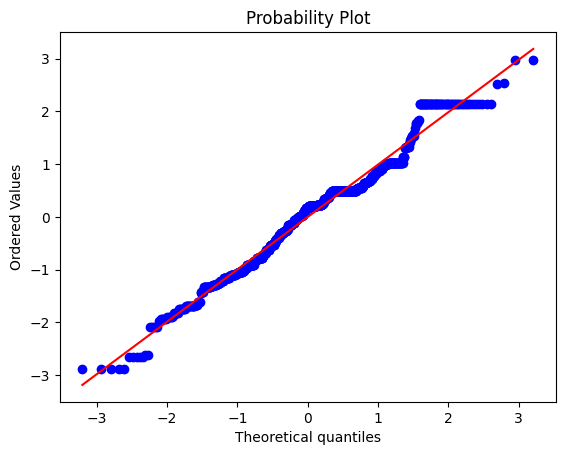

In [13]:
pt3 = PowerTransformer()
df['water_pt3'] = pt3.fit_transform(df[['water']])
stats.probplot(df['water_pt3'],dist='norm',plot=plt)

In [14]:
df.rename(columns={'coarseaggregate':'CA'},inplace= True)
df.drop(columns=['water_pt','water_pt2','water_pt3'],inplace=True)
df.head()

,cement,slag,flyash,water,superplasticizer,CA,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


((array([-3.20610174, -2.94154129, -2.79394753, ...,  2.79394753,
          2.94154129,  3.20610174]),
  array([-2.19170023, -2.19170023, -2.19170023, ...,  2.09361976,
          2.09361976,  2.23420922])),
 (np.float64(0.994558740399688),
  np.float64(-2.7045017708526053e-15),
  np.float64(0.9918657125646634)))

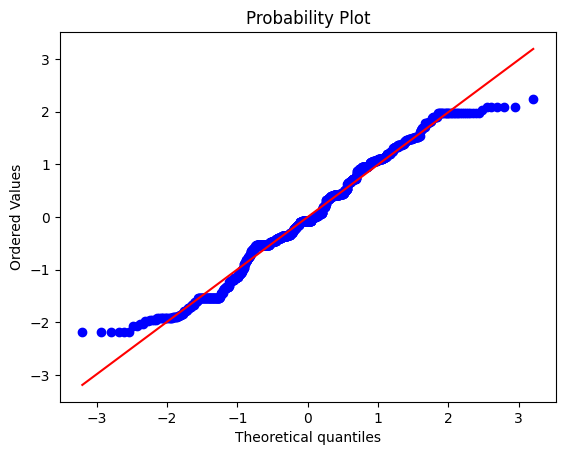

In [15]:
df['ca_pt'] = pt.fit_transform(df[['CA']])
stats.probplot(df['ca_pt'],dist='norm',plot=plt)

((array([-3.20610174, -2.94154129, -2.79394753, ...,  2.79394753,
          2.94154129,  3.20610174]),
  array([ 801. ,  801. ,  801. , ..., 1134.3, 1134.3, 1145. ])),
 (np.float64(77.28975192555822),
  np.float64(972.9189320388349),
  np.float64(0.9918198464624585)))

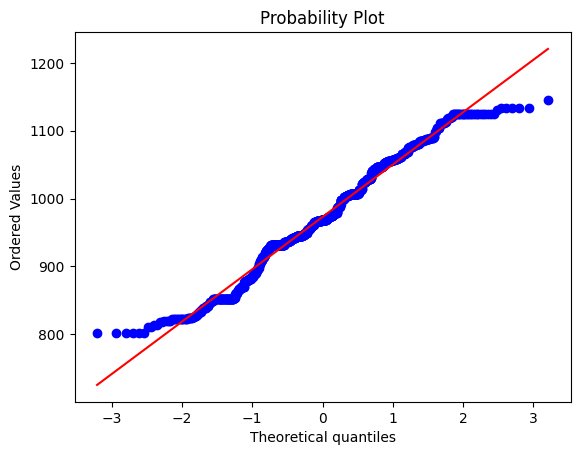

In [16]:
stats.probplot(df['CA'],dist='norm',plot=plt)


In [17]:
print(pt.lambdas_)
print(pt2.lambdas_)
print(pt3.lambdas_)


[1.12916698]
[0.80956805]
[0.80843806]
